<a href="https://colab.research.google.com/github/YoungJang-KR/semiconductor-fault-detection/blob/main/from_scratch_02_PHM18_etching.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
# 10_M02 장비 제외하기

import pandas as pd
import os
import glob

dir_train = '/content/drive/MyDrive/phm18/train'
dir_ttf = '/content/drive/MyDrive/phm18/train_ttf'

files_train = sorted( glob.glob(os.path.join(dir_train, '*csv')) )
files_ttf = sorted( glob.glob(os.path.join(dir_ttf, '*csv')) )

exclude_tools = ['10_M02']
files_train = [ f for f in files_train if not any(tool in f for tool in exclude_tools) ]
files_ttf = [ f for f in files_ttf if not any(tool in f for tool in exclude_tools) ]

print(f"10_M02 제외 후 train 파일 개수 {len(files_train)}개")
print("10_M02 제외 후 train 파일 목록:", files_train)
print(f"10_M02 제외 후 train_ttf 파일 개수 {len(files_ttf)}개")
print("10_M02 제외 후 train_ttf 파일 목록", files_ttf)

10_M02 제외 후 train 파일 개수 19개
10_M02 제외 후 train 파일 목록: ['/content/drive/MyDrive/phm18/train/01_M01_DC_train.csv', '/content/drive/MyDrive/phm18/train/01_M02_DC_train.csv', '/content/drive/MyDrive/phm18/train/02_M01_DC_train.csv', '/content/drive/MyDrive/phm18/train/02_M02_DC_train.csv', '/content/drive/MyDrive/phm18/train/03_M01_DC_train.csv', '/content/drive/MyDrive/phm18/train/03_M02_DC_train.csv', '/content/drive/MyDrive/phm18/train/04_M01_DC_train.csv', '/content/drive/MyDrive/phm18/train/04_M02_DC_train.csv', '/content/drive/MyDrive/phm18/train/05_M01_DC_train.csv', '/content/drive/MyDrive/phm18/train/05_M02_DC_train.csv', '/content/drive/MyDrive/phm18/train/06_M01_DC_train.csv', '/content/drive/MyDrive/phm18/train/06_M02_DC_train.csv', '/content/drive/MyDrive/phm18/train/07_M01_DC_train.csv', '/content/drive/MyDrive/phm18/train/07_M02_DC_train.csv', '/content/drive/MyDrive/phm18/train/08_M01_DC_train.csv', '/content/drive/MyDrive/phm18/train/08_M02_DC_train.csv', '/content/drive/My

In [3]:
# 10_M02 장비를 제외하고, 5% 샘플링 진행

dfs = []

for file_train, file_ttf in zip(files_train, files_ttf):
  df_train = pd.read_csv(file_train)
  df_ttf = pd.read_csv(file_ttf)
  df_merged = df_train.merge(df_ttf, on='time')
  df_sampled = df_merged.sample(frac=0.05, random_state=42)
  dfs.append(df_sampled)
  print(f"{file_train} 처리 완료, {df_sampled.shape}")

df_sampled_5pct = pd.concat(dfs, axis=0, ignore_index=True)
print(df_sampled_5pct.shape)

/content/drive/MyDrive/phm18/train/01_M01_DC_train.csv 처리 완료, (156787, 27)
/content/drive/MyDrive/phm18/train/01_M02_DC_train.csv 처리 완료, (256299, 27)
/content/drive/MyDrive/phm18/train/02_M01_DC_train.csv 처리 완료, (143443, 27)
/content/drive/MyDrive/phm18/train/02_M02_DC_train.csv 처리 완료, (207446, 27)
/content/drive/MyDrive/phm18/train/03_M01_DC_train.csv 처리 완료, (171722, 27)
/content/drive/MyDrive/phm18/train/03_M02_DC_train.csv 처리 완료, (253152, 27)
/content/drive/MyDrive/phm18/train/04_M01_DC_train.csv 처리 완료, (255066, 27)
/content/drive/MyDrive/phm18/train/04_M02_DC_train.csv 처리 완료, (222643, 27)
/content/drive/MyDrive/phm18/train/05_M01_DC_train.csv 처리 완료, (241018, 27)
/content/drive/MyDrive/phm18/train/05_M02_DC_train.csv 처리 완료, (96308, 27)
/content/drive/MyDrive/phm18/train/06_M01_DC_train.csv 처리 완료, (190878, 27)
/content/drive/MyDrive/phm18/train/06_M02_DC_train.csv 처리 완료, (255374, 27)
/content/drive/MyDrive/phm18/train/07_M01_DC_train.csv 처리 완료, (266162, 27)
/content/drive/MyDrive/phm

In [4]:
df_sampled_5pct.to_csv('/content/drive/MyDrive/phm18/df_sampled_5pct', index=False)
# index=False는 항상 빼먹지 않기
print("저장 완료!")

저장 완료!


In [5]:
# 불러와보기

df_ex_5pct = pd.read_csv('/content/drive/MyDrive/phm18/df_sampled_5pct')
print("행, 렬:", df_ex_5pct.shape)
print("열 항목:", df_ex_5pct.columns.tolist())

행, 렬: (3933490, 27)
열 항목: ['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION', 'TTF_FlowCool Pressure Dropped Below Limit', 'TTF_Flowcool Pressure Too High Check Flowcool Pump', 'TTF_Flowcool leak']


In [6]:
# 열 항목 이름 축약

df_ex_5pct = df_ex_5pct.rename( columns={
    'TTF_FlowCool Pressure Dropped Below Limit': 'TTF_pressure_drop',
    'TTF_Flowcool Pressure Too High Check Flowcool Pump': 'TTF_pressure_high',
    'TTF_Flowcool leak': 'TTF_leak'
})

print("열 항목:", df_ex_5pct.columns.tolist())

열 항목: ['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION', 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']


In [7]:
df_ex_5pct.to_csv('/content/drive/MyDrive/phm18/df_ex_5pct.csv', index=False)
print("저장 완료!")

저장 완료!


In [8]:
df_ex_5pct = pd.read_csv('/content/drive/MyDrive/phm18/df_ex_5pct.csv')
print("열 항목:", df_ex_5pct.columns.tolist())

열 항목: ['time', 'Tool', 'stage', 'Lot', 'runnum', 'recipe', 'recipe_step', 'IONGAUGEPRESSURE', 'ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLFLOWRATE', 'FLOWCOOLPRESSURE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK', 'FIXTURETILTANGLE', 'ROTATIONSPEED', 'ACTUALROTATIONANGLE', 'FIXTURESHUTTERPOSITION', 'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER', 'ACTUALSTEPDURATION', 'TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']


In [10]:
# 샘플링이 잘 되었는지 확인
thresholds_by_tool = df_ex_5pct.groupby('Tool')['TTF_pressure_high'].quantile(0.25)
print(thresholds_by_tool)

Tool
01M01    1843292.0
01M02    2218276.0
02M01    1106516.0
02M02     396036.0
03M01     414760.5
03M02     408913.0
04M01     205543.0
04M02          NaN
05M01    2022720.0
05M02    1461812.0
06M01    4292863.0
06M02    5172018.0
07M01    3886175.0
07M02     816479.0
08M01     923062.0
08M02    2779984.0
09M01    5080703.0
09M02     472198.0
10M01    1305850.0
Name: TTF_pressure_high, dtype: float64


04M02 장비를 제외(NaN)하고는 1% 샘플링 때와 큰 차이가 없다.


In [11]:
# 샘플링된 04M02 장비 데이터 확인하기

print( df_ex_5pct[df_ex_5pct['Tool']=='04M02'].isna().sum() )
print( df_ex_5pct[df_ex_5pct['Tool']=='04M02'].count() )

time                            0
Tool                            0
stage                           0
Lot                             0
runnum                          0
recipe                          0
recipe_step                     0
IONGAUGEPRESSURE                0
ETCHBEAMVOLTAGE                 0
ETCHBEAMCURRENT                 0
ETCHSUPPRESSORVOLTAGE           0
ETCHSUPPRESSORCURRENT           0
FLOWCOOLFLOWRATE                0
FLOWCOOLPRESSURE                0
ETCHGASCHANNEL1READBACK         0
ETCHPBNGASREADBACK              0
FIXTURETILTANGLE                0
ROTATIONSPEED                   0
ACTUALROTATIONANGLE             0
FIXTURESHUTTERPOSITION          0
ETCHSOURCEUSAGE                 0
ETCHAUXSOURCETIMER              0
ETCHAUX2SOURCETIMER             0
ACTUALSTEPDURATION              0
TTF_pressure_drop            4414
TTF_pressure_high          222643
TTF_leak                    11455
dtype: int64
time                       222643
Tool                       222643
s

In [31]:
# 04M02 장비의 전체 데이터 확인하기

df_04M02_full = pd.read_csv(files_ttf[7])
print("04M02 장비의 전체 행과 열:", df_04M02_full.shape)

print("04M02 장비 데이터의 전체 행:", len(df_04M02_full))
print("04M02 장비 데이터의 결측값:", df_04M02_full['TTF_Flowcool Pressure Too High Check Flowcool Pump'].isna().sum())
print("04M02 장비 데이터에 존재하는 TTF_pressure_high 값:", df_04M02_full['TTF_Flowcool Pressure Too High Check Flowcool Pump'].count())

04M02 장비의 전체 행과 열: (4450348, 4)
04M02 장비 데이터의 전체 행: 4450348
04M02 장비 데이터의 결측값: 4450348
04M02 장비 데이터에 존재하는 TTF_pressure_high 값: 0


고장 데이터가 1%가 넘는데, 5% 랜덤 샘플링에서 샘플링이 안 됐다. 고장 데이터가 한 곳에 몰려있어서 랜덤 샘플링으로는 정확한 분석이 어려운 경우일 수 있다.

In [18]:
sensor_cols = ['IONGAUGEPRESSURE', 'ETCHSUPPRESSORCURRENT', 'FLOWCOOLPRESSURE',
               'ACTUALROTATIONANGLE', 'ACTUALSTEPDURATION']

control_cols = ['ETCHBEAMVOLTAGE', 'ETCHBEAMCURRENT', 'ETCHSUPPRESSORVOLTAGE',
                'FLOWCOOLFLOWRATE', 'ETCHGASCHANNEL1READBACK', 'ETCHPBNGASREADBACK',
                'FIXTURETILTANGLE', 'ROTATIONSPEED', 'FIXTURESHUTTERPOSITION',
                'ETCHSOURCEUSAGE', 'ETCHAUXSOURCETIMER', 'ETCHAUX2SOURCETIMER']

train_cols = ['TTF_pressure_drop', 'TTF_pressure_high', 'TTF_leak']

In [21]:
df_04M02_train = pd.read_csv(files_train[6])
df_04M02_ttf = pd.read_csv(files_ttf[6])

df_04M02_merged = df_04M02_train.merge(df_04M02_ttf, on='time')

In [22]:
df_04M02_merged = df_04M02_merged.rename( columns={
    'TTF_FlowCool Pressure Dropped Below Limit': 'TTF_pressure_drop',
    'TTF_Flowcool Pressure Too High Check Flowcool Pump': 'TTF_pressure_high',
    'TTF_Flowcool leak': 'TTF_leak'
})

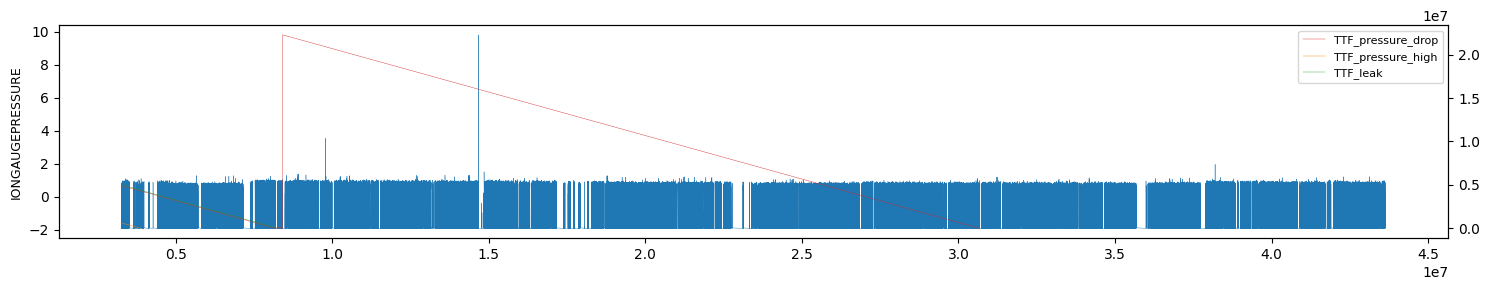

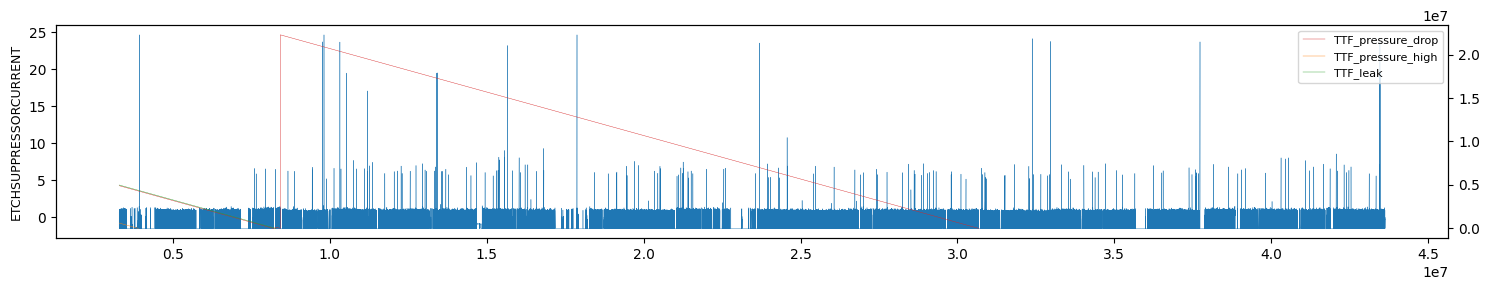

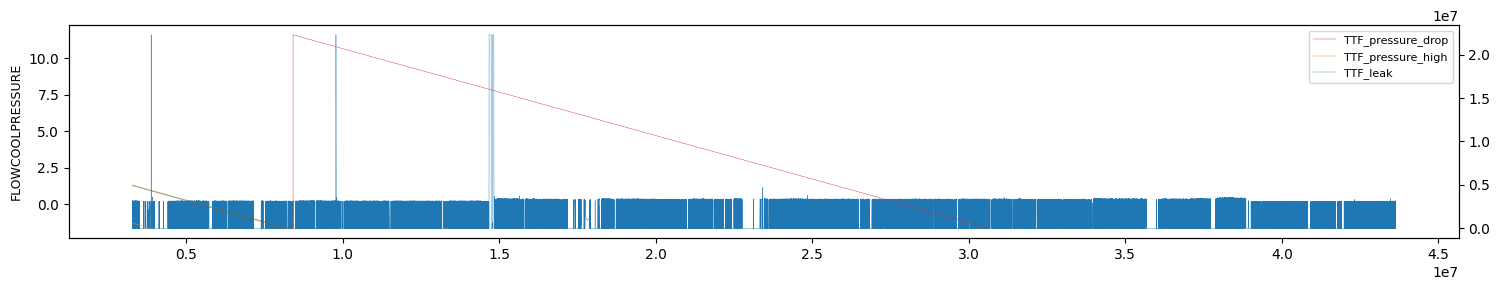

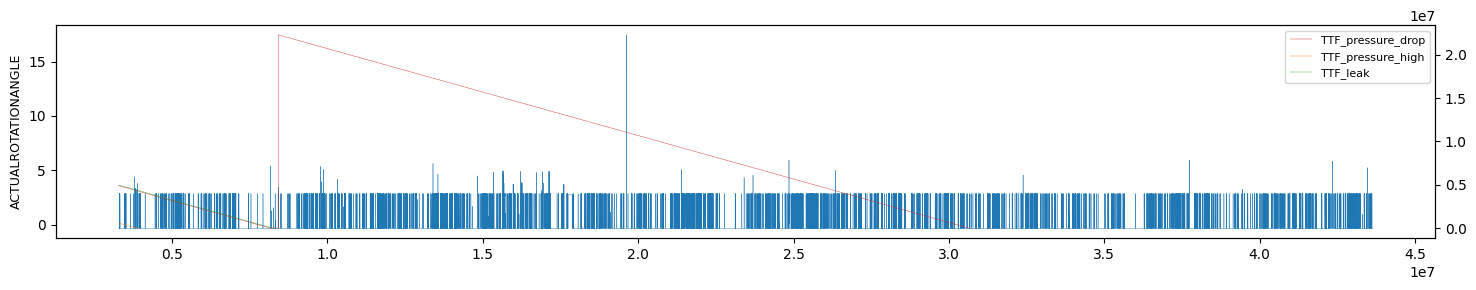

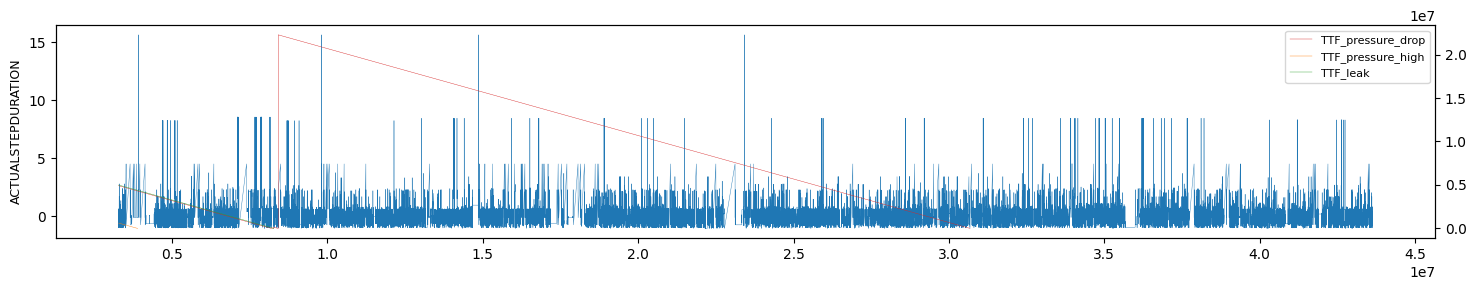

In [23]:
import matplotlib.pyplot as plt

for col in sensor_cols:
  fig, ax1 = plt.subplots(figsize=(15, 3))
  ax1.plot( df_04M02_merged['time'], df_04M02_merged[col], linewidth=0.3,
           color='tab:blue', label=col)
  ax1.set_ylabel(col, fontsize=9)

  ax2 = ax1.twinx()
  ax2.plot( df_04M02_merged['time'], df_04M02_merged['TTF_pressure_drop'], linewidth=0.3,
           color='tab:red', label='TTF_pressure_drop')
  ax2.plot( df_04M02_merged['time'], df_04M02_merged['TTF_pressure_high'], linewidth=0.3,
           color='tab:orange', label='TTF_pressure_high')
  ax2.plot( df_04M02_merged['time'], df_04M02_merged['TTF_leak'], linewidth=0.3,
           color='tab:green', label='TTF_leak')
  ax2.legend(fontsize=8, loc='upper right')

  plt.tight_layout()
  plt.show()

In [24]:
results = []

col = 'TTF_Flowcool Pressure Too High Check Flowcool Pump'

for file_train, file_ttf in zip(files_train, files_ttf):
  df_train = pd.read_csv(file_train)
  df_ttf = pd.read_csv(file_ttf)
  df_merged = df_train.merge(df_ttf, on='time')

  t_min = df_merged['time'].min()
  t_max = df_merged['time'].max()
  full_range = t_max - t_min

  df_real = df_merged[ df_merged[col].notna() ]

# 실제값이 하나도 없는 장비는 따로 처리
  if len(df_real) == 0:
    real_range = 0
    ratio = 0
  else:
    real_t_min = df_real['time'].min()
    real_t_max = df_real['time'].max()
    real_range = real_t_max - real_t_min
    ratio = real_range / full_range

  tool_name = df_merged['Tool'].iloc[0]

  results.append({
      '장비': tool_name,
      '실제값개수': len(df_real),
      '전체 범위': full_range,
      '실제값범위': real_range,
      '비율(%)': ratio*100
      })
  print(f"{tool_name} 처리 완료")

01M01 처리 완료
01M02 처리 완료
02M01 처리 완료
02M02 처리 완료
03M01 처리 완료
03M02 처리 완료
04M01 처리 완료
04M02 처리 완료
05M01 처리 완료
05M02 처리 완료
06M01 처리 완료
06M02 처리 완료
07M01 처리 완료
07M02 처리 완료
08M01 처리 완료
08M02 처리 완료
09M01 처리 완료
09M02 처리 완료
10M01 처리 완료


In [29]:
df_results = pd.DataFrame(results)
print(df_results)

df_results.to_csv('/content/drive/MyDrive/phm18/df_results.csv')
print("저장 완료!")

       장비    실제값개수     전체 범위     실제값범위      비율(%)
0   01M01  2977064  39754230  37281548  93.780078
1   01M02  3773332  36506006  28143516  77.092838
2   02M01  2713658  29211252  26449134  90.544335
3   02M02  4107779  33201886  32740726  98.611043
4   03M01  3264567  38371418  36681918  95.596983
5   03M02  5056399  40745008  40690324  99.865790
6   04M01    53818  40344760    614782   1.523821
7   04M02        0  38501702         0   0.000000
8   05M01  4015080  39354726  32409508  82.352264
9   05M02  1790699  39967854  36326292  90.888773
10  06M01  3746295  38467000  37800058  98.266197
11  06M02  5047812  37316424  36896214  98.873927
12  07M01  3643524  39171374  26440968  67.500742
13  07M02   487773  37137096   4318682  11.629025
14  08M01  3671152  35787938  35270492  98.554133
15  08M02  4142438  39752230  32728078  82.330169
16  09M01  4525772  40008890  39536254  98.818673
17  09M02  2697921  42286376  41754068  98.741183
18  10M01   465897  40135890   5330290  13.280607


In [30]:
# files_train에서 실제로 04M01, 04M02가 몇 번째 인덱스인지 확인
for i, f in enumerate(files_train):
    if '04' in f:
        print(i, f)

6 /content/drive/MyDrive/phm18/train/04_M01_DC_train.csv
7 /content/drive/MyDrive/phm18/train/04_M02_DC_train.csv
